<font size="6">3.1 一元线性回归</font>

<font size="5">3.1.3 案例实战：工作年限与收入的线性回归模型</font>

In [13]:
#读取数据
import pandas as pd
df = pd.read_excel(r"D:\1Ftostudy\商业数据分析\@Python大数据分析与机器学习商业案例实战\@Python大数据分析与机器学习商业案例实战\第3章 线性回归模型\源代码汇总_PyCharm格式\IT行业收入表.xlsx")
df.head()

,工龄,薪水
0,0.0,10808
1,0.1,13611
2,0.2,12306
3,0.3,12151
4,0.3,13057


In [15]:
# 此时的工龄为自变量，薪水为因变量，通过如下代码进行自变量、因变量选取
X = df[['工龄']]
Y = df['薪水']

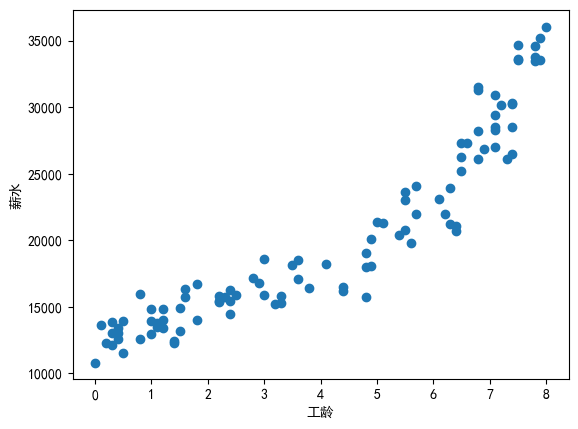

In [17]:
# 通过如下代码可以将此时的散点图绘制出来：
from matplotlib import pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.scatter(X,Y)
plt.xlabel('工龄')
plt.ylabel('薪水')
plt.show()

<font size="4">模型1：多项式回归</font>

In [20]:
#模型搭建
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

poly_reg = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('linear', LinearRegression())
])
poly_reg.fit(X, Y)        

Pipeline(steps=[('poly', PolynomialFeatures()), ('linear', LinearRegression())])

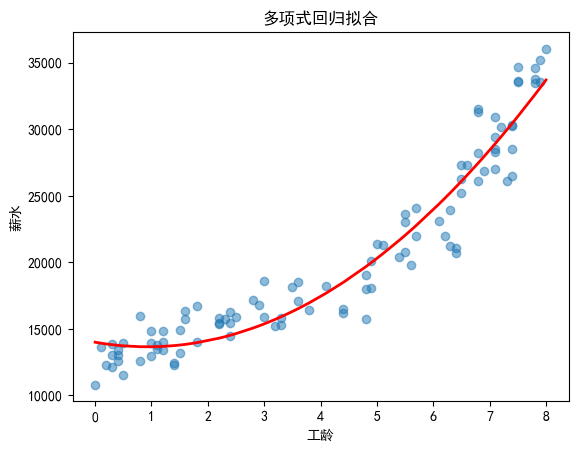

In [24]:
#模型可视化
import numpy as np

X_sorted = np.sort(X.values.flatten())
X_test = X_sorted.reshape(-1, 1)

plt.scatter(X, Y, alpha=0.5)
plt.plot(X_test, poly_reg.predict(X_test), color='red', linewidth=2)
plt.xlabel('工龄')
plt.ylabel('薪水')
plt.title('多项式回归拟合')
plt.show()

In [26]:
#线性回归方程构造
poly_features = poly_reg.named_steps['poly']
linear_model = poly_reg.named_steps['linear']

coefficients = linear_model.coef_
intercept = linear_model.intercept_

print('多项式回归系数:', coefficients)
print('截距:', intercept)
print(f'所以此时的二次多项式回归方程为: y = {coefficients[2]:.2f}×x² + {coefficients[1]:.2f}×x + {intercept:.2f}')

多项式回归系数: [   0.         -743.68080444  400.80398224]
截距: 13988.159332096873
所以此时的二次多项式回归方程为: y = 400.80×x² + -743.68×x + 13988.16


<font size="4">模型2：决策树回归</font>

In [29]:
#模型搭建
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_reg.fit(X, Y)

DecisionTreeRegressor(max_depth=3, random_state=42)

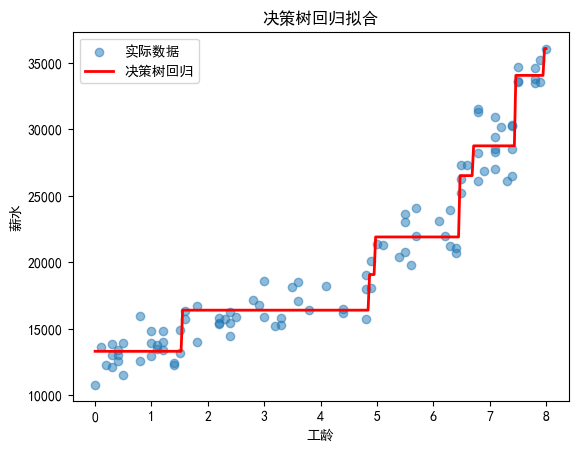

In [33]:
#模型可视化
import pandas as pd
import numpy as np

# 生成测试数据并保持特征名称
X_range = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
X_range_df = pd.DataFrame(X_range, columns=['工龄'])  # 明确指定列名

y_tree_pred = tree_reg.predict(X_range_df)

plt.scatter(X, Y, alpha=0.5, label='实际数据')
plt.plot(X_range, y_tree_pred, color='red', linewidth=2, label='决策树回归')
plt.xlabel('工龄')
plt.ylabel('薪水')
plt.title('决策树回归拟合')
plt.legend()
plt.show()

In [35]:
# 模型分析
from sklearn.tree import export_text

# 输出决策树规则
tree_rules = export_text(tree_reg, feature_names=['工龄'])
print('决策树结构规则:')
print(tree_rules)

# 评估模型性能
from sklearn.metrics import r2_score
y_pred = tree_reg.predict(X)
print(f'决策树回归 R² 分数: {r2_score(Y, y_pred):.4f}')

决策树结构规则:
|--- 工龄 <= 6.45
|   |--- 工龄 <= 4.85
|   |   |--- 工龄 <= 1.55
|   |   |   |--- value: [13304.56]
|   |   |--- 工龄 >  1.55
|   |   |   |--- value: [16395.45]
|   |--- 工龄 >  4.85
|   |   |--- 工龄 <= 4.95
|   |   |   |--- value: [19073.00]
|   |   |--- 工龄 >  4.95
|   |   |   |--- value: [21895.60]
|--- 工龄 >  6.45
|   |--- 工龄 <= 7.45
|   |   |--- 工龄 <= 6.70
|   |   |   |--- value: [26504.75]
|   |   |--- 工龄 >  6.70
|   |   |   |--- value: [28741.94]
|   |--- 工龄 >  7.45
|   |   |--- 工龄 <= 7.95
|   |   |   |--- value: [34034.75]
|   |   |--- 工龄 >  7.95
|   |   |   |--- value: [36053.00]

决策树回归 R² 分数: 0.9671


<font size="4">模型3：支持向量机回归</font>

In [38]:
#模型搭建
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# 数据标准化（SVM对数据尺度敏感）
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
Y_scaled = scaler_Y.fit_transform(Y.values.reshape(-1, 1)).ravel()

# 创建SVM回归模型
svm_reg = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svm_reg.fit(X_scaled, Y_scaled)

SVR()

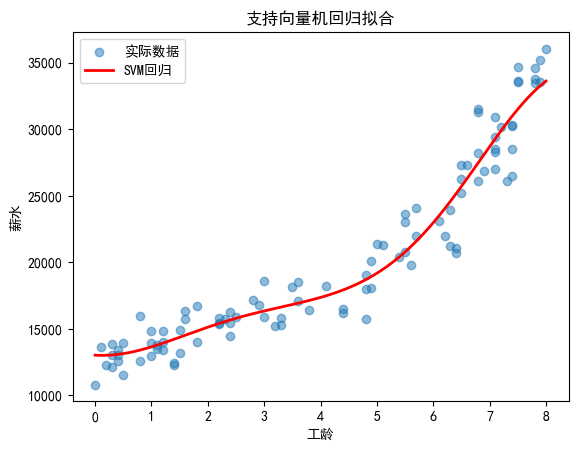

In [42]:
# 模型可视化
import pandas as pd

X_plot = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
# 将numpy数组转换为DataFrame，保持特征名称
X_plot_df = pd.DataFrame(X_plot, columns=X.columns)

X_plot_scaled = scaler_X.transform(X_plot_df)
y_svm_pred_scaled = svm_reg.predict(X_plot_scaled)
y_svm_pred = scaler_Y.inverse_transform(y_svm_pred_scaled.reshape(-1, 1))

plt.scatter(X, Y, alpha=0.5, label='实际数据')
plt.plot(X_plot, y_svm_pred, color='red', linewidth=2, label='SVM回归')
plt.xlabel('工龄')
plt.ylabel('薪水')
plt.title('支持向量机回归拟合')
plt.legend()
plt.show()

In [46]:
# 模型分析
y_pred_scaled = svm_reg.predict(X_scaled)
y_pred = scaler_Y.inverse_transform(y_pred_scaled.reshape(-1, 1))

print('支持向量机回归模型参数:')
print(f'使用的核函数: {svm_reg.kernel}')
print(f'惩罚参数C: {svm_reg.C}')
print(f'epsilon参数: {svm_reg.epsilon}')

from sklearn.metrics import r2_score, mean_squared_error
r2 = r2_score(Y, y_pred)
mse = mean_squared_error(Y, y_pred)
print(f'SVM回归 R² 分数: {r2:.4f}')
print(f'SVM回归 均方误差: {mse:.2f}')

支持向量机回归模型参数:
使用的核函数: rbf
惩罚参数C: 1.0
epsilon参数: 0.1
SVM回归 R² 分数: 0.9427
SVM回归 均方误差: 2817300.66
